In [1]:
import sys; sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/credit_default_clean.csv")
df.shape

(29964, 24)

In [2]:
print("Overall default rate:", df["default"].mean().round(4))
df.describe().T

Overall default rate: 0.2213


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29964.0,167441.585903,129762.280262,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,29964.0,1.603724,0.489131,1.0,1.00,2.0,2.00,2.0
EDUCATION,29964.0,1.842711,0.744495,1.0,1.00,2.0,2.00,4.0
MARRIAGE,29964.0,1.557302,0.521430,1.0,1.00,2.0,2.00,3.0
AGE,29964.0,35.487652,9.219449,21.0,28.00,34.0,41.00,79.0
PAY_0,29964.0,-0.416767,1.142508,-1.0,-1.00,-1.0,-1.00,8.0
PAY_2,29964.0,-0.531571,1.146877,-1.0,-1.00,-1.0,-1.00,8.0
PAY_3,29964.0,-0.555133,1.126542,-1.0,-1.00,-1.0,-1.00,8.0
PAY_4,29964.0,-0.623949,1.067752,-1.0,-1.00,-1.0,-1.00,8.0
PAY_5,29964.0,-0.679349,1.001904,-1.0,-1.00,-1.0,-1.00,8.0


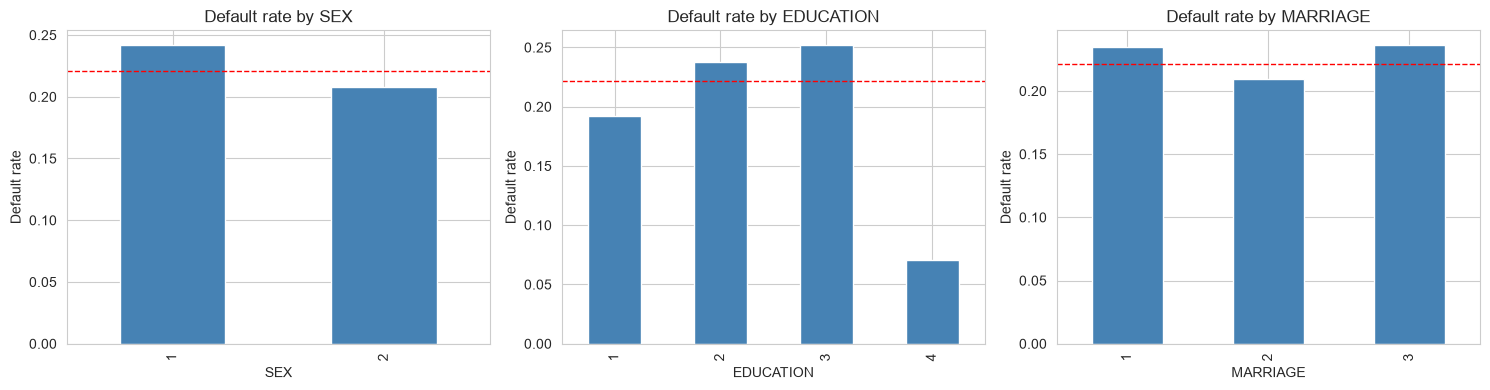

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["SEX", "EDUCATION", "MARRIAGE"]):
    rates = df.groupby(col)["default"].mean()
    rates.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("Default rate")
    ax.axhline(df["default"].mean(), color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig("../reports/figures/default_rate_by_category.png", dpi=150)
plt.show()

In [4]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    table = pd.crosstab(df[col], df["default"])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    print(f"{col}: chi2={chi2:.2f}, p={p:.4g}")

SEX: chi2=47.10, p=6.757e-12
EDUCATION: chi2=160.54, p=1.401e-34
MARRIAGE: chi2=27.52, p=1.055e-06


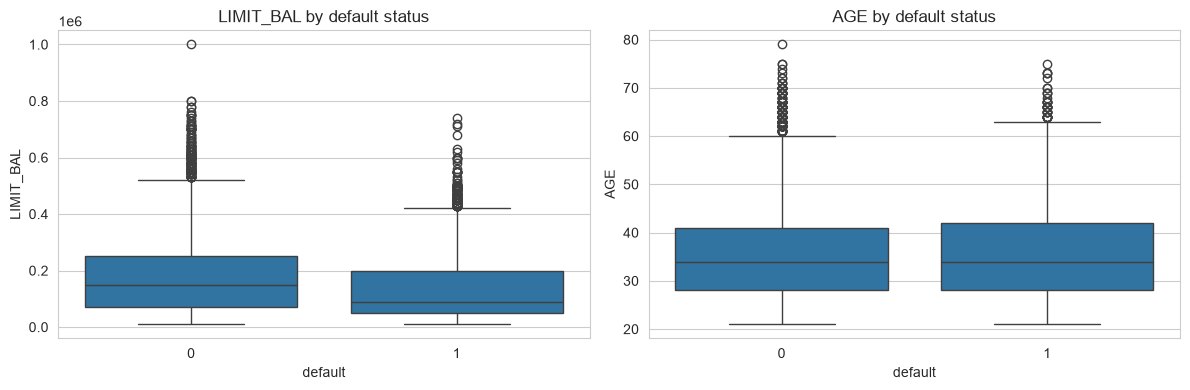

LIMIT_BAL: Mann-Whitney U=95599558, p=6.383e-190, median(no default)=150000.0, median(default)=90000.0
AGE: Mann-Whitney U=76831230, p=0.4016, median(no default)=34.0, median(default)=34.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ["LIMIT_BAL", "AGE"]):
    sns.boxplot(data=df, x="default", y=col, ax=ax)
    ax.set_title(f"{col} by default status")

plt.tight_layout()
plt.savefig("../reports/figures/numeric_by_default.png", dpi=150)
plt.show()

for col in ["LIMIT_BAL", "AGE"]:
    grp0 = df.loc[df["default"] == 0, col]
    grp1 = df.loc[df["default"] == 1, col]
    stat, p = stats.mannwhitneyu(grp0, grp1)
    print(f"{col}: Mann-Whitney U={stat:.0f}, p={p:.4g}, "
          f"median(no default)={grp0.median()}, median(default)={grp1.median()}")

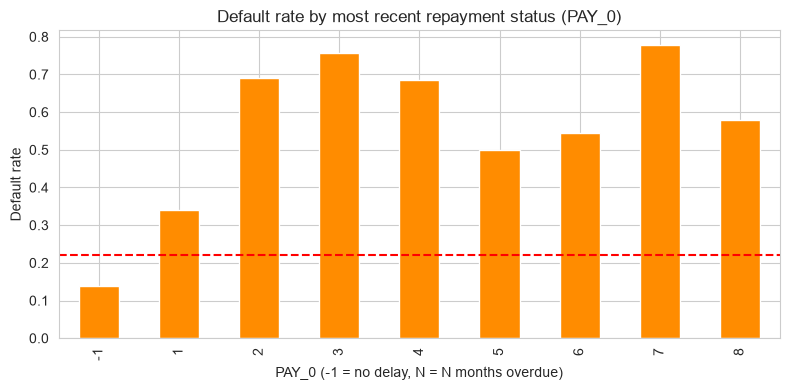

PAY_0: chi2=5324.87, p=0


In [7]:
rates = df.groupby("PAY_0")["default"].mean()
plt.figure(figsize=(8, 4))
rates.plot(kind="bar", color="darkorange")
plt.axhline(df["default"].mean(), color="red", linestyle="--")
plt.title("Default rate by most recent repayment status (PAY_0)")
plt.ylabel("Default rate")
plt.xlabel("PAY_0 (-1 = no delay, N = N months overdue)")
plt.tight_layout()
plt.savefig("../reports/figures/default_rate_by_pay0.png", dpi=150)
plt.show()

table = pd.crosstab(df["PAY_0"], df["default"])
chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"PAY_0: chi2={chi2:.2f}, p={p:.4g}")